In [1]:
### Analyze MOFA MODEL Results
### Investigate the specific top features of each factor
### Plot the normalized expression of the features as heatmap

#############################################
# Prerequisites - Load Libraries

In [2]:
source('MS1_Functions.r')

In [3]:
### Inform about execution start
popup_function_pos('05_Downstream_Investigate_Features_Heatmap: Execution Started')

In [4]:
source('MS0_Libraries.r')

[1] "/ictstr01/home/icb/bhavishya.nelakuditi/miniconda3/envs/my_jupyter_env/lib/R/library/"


Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Warning message:
“package ‘tibble’ was built under R version 4.3.3”
Warning message:
“package ‘purrr’ was built under R version 4.3.3”
Warning message:
“package ‘stringr’ was built under R version 4.3.3”
Warning message:
“package ‘forcats’ was built under R version 4.3.3”
Warning message:
“package ‘lubridate’ was built under R version 4.3.3”
── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
“packa

In [5]:
source('MS2_Plot_Config.r')

Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


###############################################
# Preqrequisites Configurations & Parameters

In [6]:
### Load the parameters that are set via the configuration files

In [7]:
### Load configurations file
global_configs = read.csv('configurations/Data_Configs.csv', sep = ',')

In [8]:
head(global_configs,2)

,parameter,value
,<chr>,<chr>
1,data_path,/ictstr01/home/icb/bhavishya.nelakuditi/mofa_workflow/input_data/
2,result_path,/ictstr01/home/icb/bhavishya.nelakuditi/mofa_workflow/results/


In [9]:
data_path = global_configs$value[global_configs$parameter == 'data_path']

In [10]:
data_path

[1] "/ictstr01/home/icb/bhavishya.nelakuditi/mofa_workflow/input_data/"

In [11]:
result_path = global_configs$value[global_configs$parameter == 'result_path']

In [12]:
result_path

[1] "/ictstr01/home/icb/bhavishya.nelakuditi/mofa_workflow/results/"

In [13]:
### Configuration parameters for plot (read and assign)

In [14]:
plot_configs =  read.csv('configurations/05_Feature_Analysis_Configs.csv', sep = ',')
plot_configs = plot_configs[plot_configs$configuration_name != '',]

In [15]:
head(plot_configs,2)

,configuration_name,mofa_result_name,factor,top_variable_thres,faceting_variable,type,plot_width,plot_height
,<chr>,<chr>,<chr>,<dbl>,<chr>,<lgl>,<int>,<int>
1,CGS_v3,CGS_v3_MOFA,Factor3,0.005,Time_point,NA,22,17


In [16]:
## Assign the values from the configuration file to the corresponding variables

In [17]:
mofa_name = plot_configs$mofa_result_name
data_name = plot_configs$configuration_name

factor_var = plot_configs$factor
top_variable_fraction = plot_configs$top_variable_thres
variable = plot_configs$faceting_variable

view_var = plot_configs$type

In [18]:
## Extract the specified plot size
width_par = plot_configs$plot_width  # 8.07 default
height_par = plot_configs$plot_height

In [19]:
### Alternative: Set configurations manually 

# Load Data 

## MOFA Input

In [20]:
### Load the normalized expression data that was used as input for the MOFA model

In [21]:
path = paste0(result_path, '/02_results/02_Combined_Data_',data_name,'_INTEGRATED.csv')
if(file.exists(path)){
    data_long = read.csv(path)
    data_long$X = NULL
    print(file.info(path)$mtime)
    popup_function_pos(paste0('Loaded: ', '02_Combined_Data_',data_name,'_INTEGRATED.csv'))
    
        } else { popup_function_neg(paste0('Error: Cannot Load: ', '02_Combined_Data_',data_name,'_INTEGRATED.csv', ' Please check whether the previous step has been executed successfully'))} 


[1] "2024-09-23 18:39:28 CEST"


In [22]:
head(data_long,2)

,sample_id,variable,value,type,gene
,<chr>,<chr>,<dbl>,<chr>,<chr>
1,HF10,Activated.T.cells__AAK1,0.4022501,Activated.T.cells,AAK1
2,HF11,Activated.T.cells__AAK1,0.0000000,Activated.T.cells,AAK1


## MOFA Model

In [23]:
### Load the trained MOFA Model

In [24]:
model_name =  paste0("03_MOFA_MODEL_", mofa_name,'.hdf5')

In [25]:
outfile = file.path( paste0(result_path, '/03_results/',  model_name) )

In [26]:
outfile

[1] "/ictstr01/home/icb/bhavishya.nelakuditi/mofa_workflow/results//03_results/03_MOFA_MODEL_CGS_v3_MOFA.hdf5"

In [27]:
if(file.exists(outfile)){
    model <- load_model(outfile, verbose = TRUE)
    popup_function_pos(paste0('Loaded: ', model_name))
    } else {popup_function_neg(paste0('Error: ',result_path, '/03_results/ ', model_name, 'could not be loaded. Check whether the previous steps have been executed successfully')) } 

Loading data...

Loading expectations for 2 nodes...

Loading model options...

Loading training options and statistics...

Assigning names to the different dimensions...

Re-ordering factors by their variance explained...

Doing quality control...

Checking views names...

Checking groups names...

Checking samples names...

Checking features names...

Checking dimensions...

Checking there are no features with complete missing values...

Checking sample covariates...

Checking expectations...

Checking for intercept factors...

Checking for highly correlated factors...



In [28]:
### Load the Factor Data of the Model

In [29]:
path = paste0(result_path, '/03_results/', '03_Factor_Data_', mofa_name, '.csv')

if(file.exists(path)){
    factors = read.csv(path)
    popup_function_pos(paste0('Loaded: ','03_Factor_Data_', mofa_name, '.csv'))
    } else {popup_function_neg(paste0('Error: ','03_Factor_Data_', mofa_name, '.csv', ' could not be loaded. Check whether the previous steps have been executed successfully'))}
    

In [30]:
head(factors,2)

,Factor1,Factor2,Factor3,Factor4,Factor5,Factor6,Factor7,Factor8,Factor9,Factor10,Factor11,Factor12,Factor13,sample_id
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,0.1553547,0.01219151,1.373604,-0.9342654,-0.08166236,0.09966231,-0.738721896,-1.4202759,0.1809295,-0.6330105,-0.33272946,0.7804502,0.6657295,HF1
2,-1.3159462,0.98926091,1.290839,0.2897947,0.50661458,-0.50892308,0.007523418,-0.2540576,0.4483722,-0.2281557,-0.07792966,-0.2514229,-0.1821789,HF10


In [31]:
### Load the Weight Data of the Model

In [32]:
path = paste0(result_path, '/03_results/', '03_Weight_Data_', mofa_name, '.csv')
if(file.exists(path)){
    weight_data = read.csv(path)
    popup_function_pos(paste0('Loaded: ','03_Weight_Data_',  mofa_name, '.csv'))} else{ popup_function_neg(paste0('Error: ','03_Weight_Data_',  mofa_name, '.csv', ' could not be loaded. Check whether the previous steps have been executed successfully and the file exists.'))} 

## Sample Meta Data

In [33]:
## Load the sample meta-data that contains covariates that can be used to group the plot

In [34]:
file_path = paste0(data_path, 'Prepared_Sample_Meta_Data', '.csv')
if(file.exists(file_path)){
    sample_data = read.csv(paste0(data_path, 'Prepared_Sample_Meta_Data', '.csv'))
    sample_data$X = NULL
    popup_function_pos(paste0('Loaded: ','Prepared_Sample_Meta_Data', '.csv'))} else{ popup_function_neg(paste0('Error: ','Prepared_Sample_Meta_Data', '.csv', ' could not be loaded. Please add the file to the specified input data folder.'))}

In [35]:
head(sample_data,2)

,sample_id,risk,risk_with_three_levels,LVEF_discharge,LVEF_outcome,catecholamine_risk,lactate_clearance,LVEF_admission,catecholamines_days,catecholamines,⋯,CRP,Leukocyte,Troponin.T,Plt.Count,IL.6,Lactate,NTproBNP,CK,CK.MB,Crea
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<dbl>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<dbl>
1,KS1.1,low_risk,low_risk_3,18,bad_LVEF,,good,20,NA,no,⋯,6.8,13.8,NA,320,15.2,2.9,NA,53,NA,0.6
2,KS2.1,high_risk,high_risk_3,NA,,good,good,NA,5,yes_catecholamines,⋯,5.5,12.0,0.049,134,46.5,3.1,7068,276,18,2.1


In [36]:
faceting_variable <- plot_configs$faceting_variable
sample_data <- sample_data %>%
  filter(!is.na(.data[[faceting_variable]]) & .data[[faceting_variable]] != "")


In [37]:
nrow(sample_data)

[1] 100

In [38]:
## Check whether faceting variable is included in sample-meta-data file

In [39]:
if (!plot_configs$faceting_variable %in% colnames(sample_data)){
    popup_function_neg(paste0('Error: ', plot_configs$faceting_variable, ' is not included in the uploaded sample data file. Specify another faceting variable or include it in the sample data file'))
    print(paste0('Error: ', plot_configs$faceting_variable, ' is not included in the uploaded sample data file. Specify another faceting variable or include it in the sample data file'))

}
    

In [40]:
## Check whether the sample_id column is included

In [41]:
if(! 'sample_id' %in% colnames(sample_data)){
    popup_function_neg(paste0('Error: ', 'columns sample_id is not included in sample data and is required'))
    print(paste0('Error: ', 'columns sample_id is not included in sample data and is required'))
}

# Downstream Analysis of generated model

## Extract and prepare data for plots

### Merge factors and sample data

In [42]:
### Combine the factor and the sample data

In [43]:
head(factors,2)

,Factor1,Factor2,Factor3,Factor4,Factor5,Factor6,Factor7,Factor8,Factor9,Factor10,Factor11,Factor12,Factor13,sample_id
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,0.1553547,0.01219151,1.373604,-0.9342654,-0.08166236,0.09966231,-0.738721896,-1.4202759,0.1809295,-0.6330105,-0.33272946,0.7804502,0.6657295,HF1
2,-1.3159462,0.98926091,1.290839,0.2897947,0.50661458,-0.50892308,0.007523418,-0.2540576,0.4483722,-0.2281557,-0.07792966,-0.2514229,-0.1821789,HF10


In [44]:
factors_long = melt(factors, id.vars = 'sample_id')

In [45]:
head(factors_long,2)

,sample_id,variable,value
,<chr>,<fct>,<dbl>
1,HF1,Factor1,0.1553547
2,HF10,Factor1,-1.3159462


In [46]:
merged_data_long = merge(factors_long, sample_data, by.x = 'sample_id', by.y = 'sample_id')

In [47]:
head(merged_data_long,2)

,sample_id,variable,value,risk,risk_with_three_levels,LVEF_discharge,LVEF_outcome,catecholamine_risk,lactate_clearance,LVEF_admission,⋯,CRP,Leukocyte,Troponin.T,Plt.Count,IL.6,Lactate,NTproBNP,CK,CK.MB,Crea
,<chr>,<fct>,<dbl>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,⋯,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<dbl>
1,HF1,Factor1,0.1553547,,,NA,,,,NA,⋯,0.1,10.9,0.031,287,NA,NA,NA,80,21,0.8
2,HF1,Factor12,0.7804502,,,NA,,,,NA,⋯,0.1,10.9,0.031,287,NA,NA,NA,80,21,0.8


### Prepare weight data

In [48]:
### Adjust the format of the feature factor weight data to long

In [49]:
feature_weights_long = melt(weight_data, id.vars = c('variable_name', 'type'))

In [50]:
feature_weights_long$view = feature_weights_long$type
feature_weights_long$gene = str_replace(feature_weights_long$variable_name, '.*__', '')

In [51]:
head(feature_weights_long,2)

,variable_name,type,variable,value,view,gene
,<chr>,<chr>,<fct>,<dbl>,<chr>,<chr>
1,Activated.T.cells__AAK1,Activated.T.cells,Factor1,0.4170012,Activated.T.cells,AAK1
2,Activated.T.cells__ABLIM1,Activated.T.cells,Factor1,-0.1381327,Activated.T.cells,ABLIM1


### Get top features per factor and for specified threshold

In [52]:
## Get the x% of top features per factor based on the specified threshold (x) in the configuration file

In [53]:
dimensions = unique(feature_weights_long[,c('view', 'variable')])

In [54]:

## Define amont of top genes per fraction 
geneset_oi_pos_per_factor_analyze = feature_weights_long %>% group_by(variable) %>% dplyr::arrange( desc(value),  .by_group = TRUE)  %>% top_frac( as.numeric(top_variable_fraction), value)
geneset_oi_pos_per_factor_analyze$direction = 'positive'

geneset_oi_neg_per_factor_analyze = feature_weights_long %>% group_by(variable) %>% dplyr::arrange(desc(value),  .by_group = TRUE)  %>% top_frac( -as.numeric(top_variable_fraction), value)
geneset_oi_neg_per_factor_analyze$direction = 'negative'

geneset_oi_analyze = rbind(geneset_oi_pos_per_factor_analyze, geneset_oi_neg_per_factor_analyze)
geneset_oi_analyze$fraction = as.numeric(top_variable_fraction)

geneset_oi_per_fraction = geneset_oi_analyze


## Calculate amount of top variables for the selected fraction
amount_geneset_oi_type = geneset_oi_analyze %>% group_by(type, view, variable) %>% dplyr::count()
amount_geneset_oi_type = merge(dimensions, amount_geneset_oi_type, all.x = TRUE)
amount_geneset_oi_type$fraction = as.numeric(top_variable_fraction)


geneset_oi_amounts =amount_geneset_oi_type


In [55]:
## Calculate total amount of features per type
features_per_type = feature_weights_long %>% group_by(type, view, variable) %>% dplyr::count()
colnames(features_per_type) = c('type', 'view', 'variable', 'amount_features')

In [56]:
## Merge top feature amounts and total amounts 
geneset_oi_amounts = merge(  geneset_oi_amounts,features_per_type, all.x = TRUE)

##  Calculate percentages
geneset_oi_amounts$percentage = geneset_oi_amounts$n / geneset_oi_amounts$amount_features

In [57]:
# Set NA when there are no features for this dimension among top %
geneset_oi_amounts[is.na(geneset_oi_amounts)] = 0 

### Prepare heatmap data (based on transformed expression values)

In [58]:
### Subset data on the selected factor (in the configuration)

In [59]:
analysis_data_subset = geneset_oi_per_fraction[geneset_oi_per_fraction$variable %in%  factor_var,]

In [60]:
### Add direction of effect

In [61]:
analysis_data_subset$direction_sign = analysis_data_subset$direction
analysis_data_subset$direction_sign[analysis_data_subset$direction == 'positive'] = '+'
analysis_data_subset$direction_sign[analysis_data_subset$direction == 'negative'] = '-'

In [62]:
head(analysis_data_subset,2)

variable_name,type,variable,value,view,gene,direction,fraction,direction_sign
<chr>,<chr>,<fct>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>
Classical.Monocytes__NLRP3,Classical.Monocytes,Factor3,0.8120541,Classical.Monocytes,NLRP3,positive,0.005,+
Classical.Monocytes__AP1S2,Classical.Monocytes,Factor3,0.8114625,Classical.Monocytes,AP1S2,positive,0.005,+


In [63]:
### Add cell-type/ type column

In [64]:
analysis_data_subset$cell_type = analysis_data_subset$type

In [65]:
### Concat direction + view for faceting on y -axis

In [66]:
analysis_data_subset$facet =  paste0(analysis_data_subset$direction_sign, analysis_data_subset$view)

In [67]:
head(analysis_data_subset,2)

variable_name,type,variable,value,view,gene,direction,fraction,direction_sign,cell_type,facet
<chr>,<chr>,<fct>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>
Classical.Monocytes__NLRP3,Classical.Monocytes,Factor3,0.8120541,Classical.Monocytes,NLRP3,positive,0.005,+,Classical.Monocytes,+Classical.Monocytes
Classical.Monocytes__AP1S2,Classical.Monocytes,Factor3,0.8114625,Classical.Monocytes,AP1S2,positive,0.005,+,Classical.Monocytes,+Classical.Monocytes


In [68]:
## Adjust column names in input data

In [69]:
data_long$expression_value = data_long$value
data_long$variable_name = data_long$variable
data_long$variable = NULL
data_long$value = NULL

In [70]:
head(data_long,2)

,sample_id,type,gene,expression_value,variable_name
,<chr>,<chr>,<chr>,<dbl>,<chr>
1,HF10,Activated.T.cells,AAK1,0.4022501,Activated.T.cells__AAK1
2,HF11,Activated.T.cells,AAK1,0.0000000,Activated.T.cells__AAK1


In [71]:
### Merge factor values and expression values

In [72]:
heatmap_data = merge(data_long, analysis_data_subset, by.x = c('variable_name'), by.y = c('variable_name'))

In [73]:
nrow(heatmap_data)

[1] 9504

In [74]:
head(heatmap_data,2)

,variable_name,sample_id,type.x,gene.x,expression_value,type.y,variable,value,view,gene.y,direction,fraction,direction_sign,cell_type,facet
,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<fct>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>
1,Activated.T.cells__AL691403.1,KS33.1,Activated.T.cells,AL691403.1,-1.9424443,Activated.T.cells,Factor3,-0.631397,Activated.T.cells,AL691403.1,negative,0.005,-,Activated.T.cells,-Activated.T.cells
2,Activated.T.cells__AL691403.1,KS36.2,Activated.T.cells,AL691403.1,0.8490862,Activated.T.cells,Factor3,-0.631397,Activated.T.cells,AL691403.1,negative,0.005,-,Activated.T.cells,-Activated.T.cells


In [75]:
### Add sample meta-data

In [76]:
heatmap_data = merge(heatmap_data, sample_data, by.x = 'sample_id', by.y = 'sample_id')

In [77]:
head(heatmap_data,2)

,sample_id,variable_name,type.x,gene.x,expression_value,type.y,variable,value,view,gene.y,⋯,CRP,Leukocyte,Troponin.T,Plt.Count,IL.6,Lactate,NTproBNP,CK,CK.MB,Crea
,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<fct>,<dbl>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<dbl>
1,HF1,Classical.Monocytes__HSPA1B,Classical.Monocytes,HSPA1B,NA,Classical.Monocytes,Factor3,-0.6441615,Classical.Monocytes,HSPA1B,⋯,0.1,10.9,0.031,287,NA,NA,NA,80,21,0.8
2,HF1,Activated.T.cells__AL691403.1,Activated.T.cells,AL691403.1,NA,Activated.T.cells,Factor3,-0.6313970,Activated.T.cells,AL691403.1,⋯,0.1,10.9,0.031,287,NA,NA,NA,80,21,0.8


# Heatmap Plot

In [78]:
###Generates heatmap based on configurations

In [79]:
## Specify figure name

In [80]:
figure_name = "FIG05_Heatmap_Feature_Overview"

In [81]:
# Specific Text Descriptions (heatmap) for x and y-axis:
xlabel_heatmap = xlab('Samples') 
ylabel_heatmap = ylab('View')

In [82]:
# Specific Text Descriptions (factor value plot) for x and y-axis:
xlabel_barplot = xlab('Samples') 
ylabel_barplot = ylab('Absolute Factor Value')

In [83]:
## Choose columns for faceting according to parameters specified in config file

In [84]:
## specify faceting for heamtap
heatmap_data$facet2 = heatmap_data[,variable] # x-axis faceting
heatmap_data$facet = paste0(heatmap_data$direction_sign, heatmap_data$view) # y-axis faceting

## specify faceting for factor value plot
analysis_data_subset$facet = paste0(analysis_data_subset$direction_sign,analysis_data_subset$view)
analysis_data_subset$facet2 = 'Absolute Factor Value'

In [85]:
view_var

[1] NA

In [86]:
##heatmap_data <- heatmap_data %>% filter(view == "Classical.Monocytes" | view == "Activated.T.cells")


In [87]:
##analysis_data_subset <- analysis_data_subset %>% filter(view == "Classical.Monocytes" | view == "Activated.T.cells")

In [88]:
## filter data on a specific view if specified in the config file
#if(view_var %in% unique(heatmap_data$view)){
#    heatmap_data = heatmap_data[heatmap_data$view %in% view_var,]
#    analysis_data_subset = analysis_data_subset[analysis_data_subset$view %in% view_var,]
#    } else{view_var = ''}

In [89]:
head(analysis_data_subset)

variable_name,type,variable,value,view,gene,direction,fraction,direction_sign,cell_type,facet,facet2
<chr>,<chr>,<fct>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
Classical.Monocytes__NLRP3,Classical.Monocytes,Factor3,0.8120541,Classical.Monocytes,NLRP3,positive,0.005,+,Classical.Monocytes,+Classical.Monocytes,Absolute Factor Value
Classical.Monocytes__AP1S2,Classical.Monocytes,Factor3,0.8114625,Classical.Monocytes,AP1S2,positive,0.005,+,Classical.Monocytes,+Classical.Monocytes,Absolute Factor Value
Classical.Monocytes__LINC01588,Classical.Monocytes,Factor3,0.7734370,Classical.Monocytes,LINC01588,positive,0.005,+,Classical.Monocytes,+Classical.Monocytes,Absolute Factor Value
Classical.Monocytes__PNRC1,Classical.Monocytes,Factor3,0.7632843,Classical.Monocytes,PNRC1,positive,0.005,+,Classical.Monocytes,+Classical.Monocytes,Absolute Factor Value
Classical.Monocytes__SERPINB9,Classical.Monocytes,Factor3,0.7535938,Classical.Monocytes,SERPINB9,positive,0.005,+,Classical.Monocytes,+Classical.Monocytes,Absolute Factor Value
Classical.Monocytes__SEPTIN4.AS1,Classical.Monocytes,Factor3,0.7506818,Classical.Monocytes,SEPTIN4.AS1,positive,0.005,+,Classical.Monocytes,+Classical.Monocytes,Absolute Factor Value


In [90]:
head(heatmap_data,2)

,sample_id,variable_name,type.x,gene.x,expression_value,type.y,variable,value,view,gene.y,⋯,Leukocyte,Troponin.T,Plt.Count,IL.6,Lactate,NTproBNP,CK,CK.MB,Crea,facet2
,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<fct>,<dbl>,<chr>,<chr>,⋯,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<dbl>,<chr>
1,HF1,Classical.Monocytes__HSPA1B,Classical.Monocytes,HSPA1B,NA,Classical.Monocytes,Factor3,-0.6441615,Classical.Monocytes,HSPA1B,⋯,10.9,0.031,287,NA,NA,NA,80,21,0.8,TP0/HF
2,HF1,Activated.T.cells__AL691403.1,Activated.T.cells,AL691403.1,NA,Activated.T.cells,Factor3,-0.6313970,Activated.T.cells,AL691403.1,⋯,10.9,0.031,287,NA,NA,NA,80,21,0.8,TP0/HF


In [91]:
write.csv(heatmap_data, "/ictstr01/home/icb/bhavishya.nelakuditi/mofa_workflow/results/factor3_heatmap_conditin.csv")

In [92]:
# Plot factor values as barplot

In [93]:
options(repr.plot.width=10, repr.plot.height=25)
factor_value_all_bar = ggplot(data = analysis_data_subset[(analysis_data_subset$variable == factor_var),] , 
                              mapping = aes(x = gene,   y= abs(value)))+
                            plot_config_heatmap_supp  + 
                            geom_bar(stat="identity", width = 0.1) + 
                            coord_flip()+
                            xlabel_barplot +
                            ylabel_barplot +
                            theme( axis.text.y = element_text( hjust = 1, vjust =1))+
                            facet_grid(facet  ~ facet2, scales = 'free', space = 'free', switch = 'y') + theme(strip.background = element_rect(color="black", fill="white", linetype="solid"), strip.placement = "outside", strip.switch.pad.grid = unit(0.5, "cm"))+
                            ggtitle('')


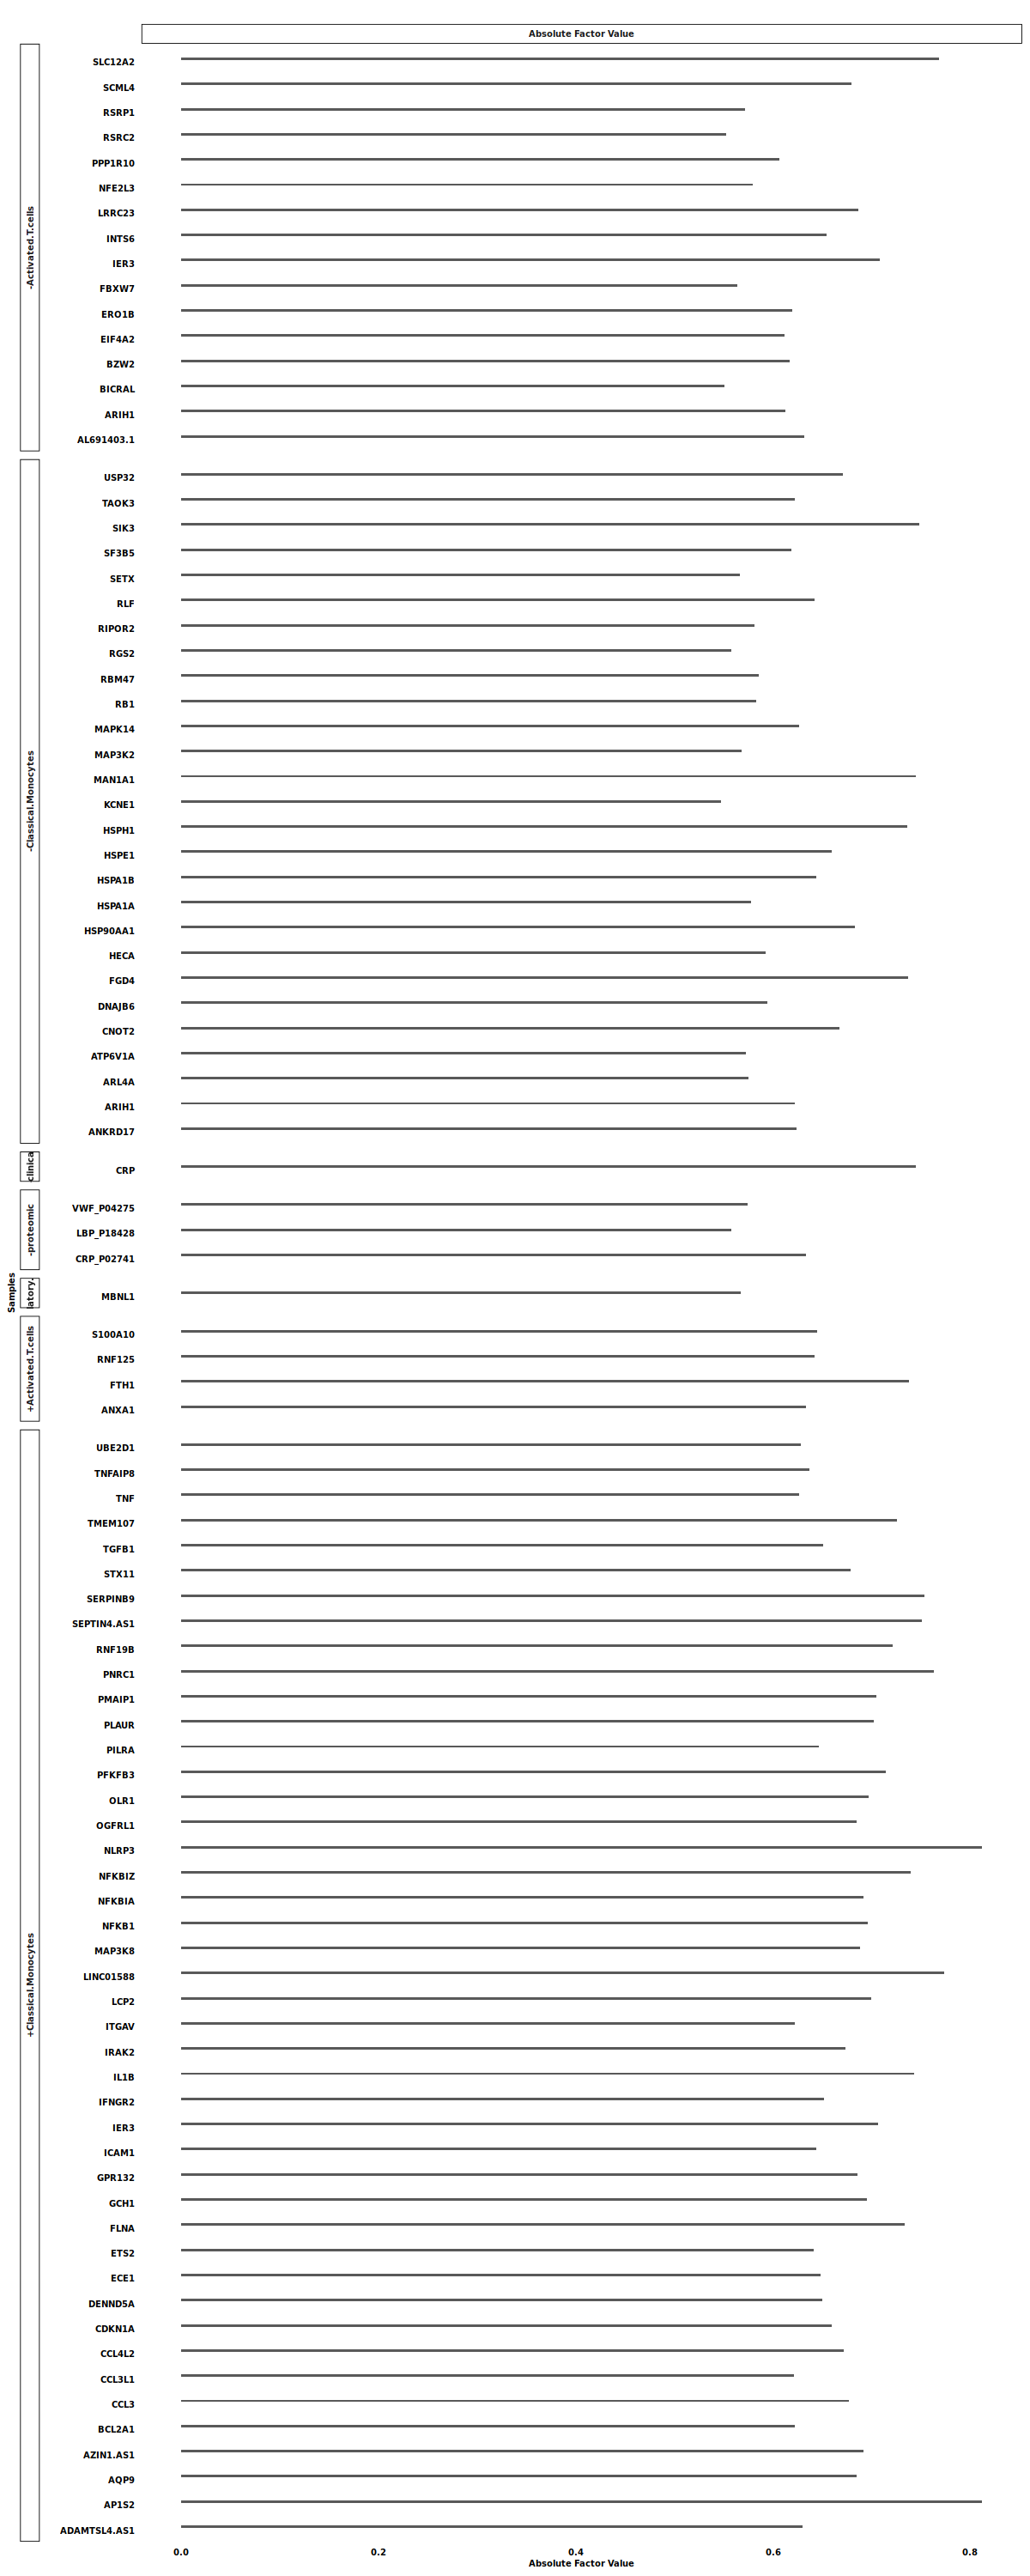

In [94]:
# Example of plot
factor_value_all_bar

In [95]:
### Generate Heatmap Plot

In [96]:
factor_var

[1] "Factor3"

In [97]:
options(repr.plot.width=width_par, repr.plot.height=height_par)
all_heatmap = ggplot(data = heatmap_data[(heatmap_data$variable == factor_var) ,], # TBD whether to filter on sample subset
                     mapping = aes(sample_id, gene.x,  fill= expression_value)) +
    scale_fill_gradient2(low="#1D2ED8", high="#D8911D", midpoint = 0) + 
    geom_tile() + 
    xlabel_heatmap +
    ylabel_heatmap +
    #plot_config_heatmap_supp  + theme(axis.text.x = element_blank()) + 
    facet_grid(facet  ~facet2, scales = 'free', space = 'free',  switch = "y") + theme(strip.background = element_rect(color="black", fill="white", linetype="solid"), strip.placement = "outside", strip.switch.pad.grid = unit(0.4, "cm"), strip.text.y.left = element_text(angle=0),axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1))+
    theme( axis.text.y = element_text( hjust = 1, vjust =1)) + 
    ggtitle(paste0('Normalized Expression Values of top ',as.numeric(top_variable_fraction) *100 *2, '% features'))

    

In [98]:
all_heatmap = ggplot(data = heatmap_data[(heatmap_data$variable == factor_var) ,],
                     mapping = aes(sample_id, gene.x,  fill= expression_value)) +
    scale_fill_gradient2(low="#1D2ED8", high="#D81D1D", midpoint = 0) +  # Changed to red
    geom_tile() + 
    xlabel_heatmap +
    ylabel_heatmap +
    facet_grid(facet  ~facet2, scales = 'free', space = 'free',  switch = "y") + 
    theme(strip.background = element_rect(color="black", fill="white", linetype="solid"), 
          strip.placement = "outside", 
          strip.switch.pad.grid = unit(0.4, "cm"), 
          strip.text.y.left = element_text(angle=0),
          axis.text.x = element_blank(),  # Removes sample names
          axis.ticks.x = element_blank(),  # Removes x-axis ticks too
          axis.text.y = element_text(hjust = 1, vjust = 1)) + 
    ggtitle(paste0('Normalized Expression Values of top ',as.numeric(top_variable_fraction) *100 *2, '% features'))

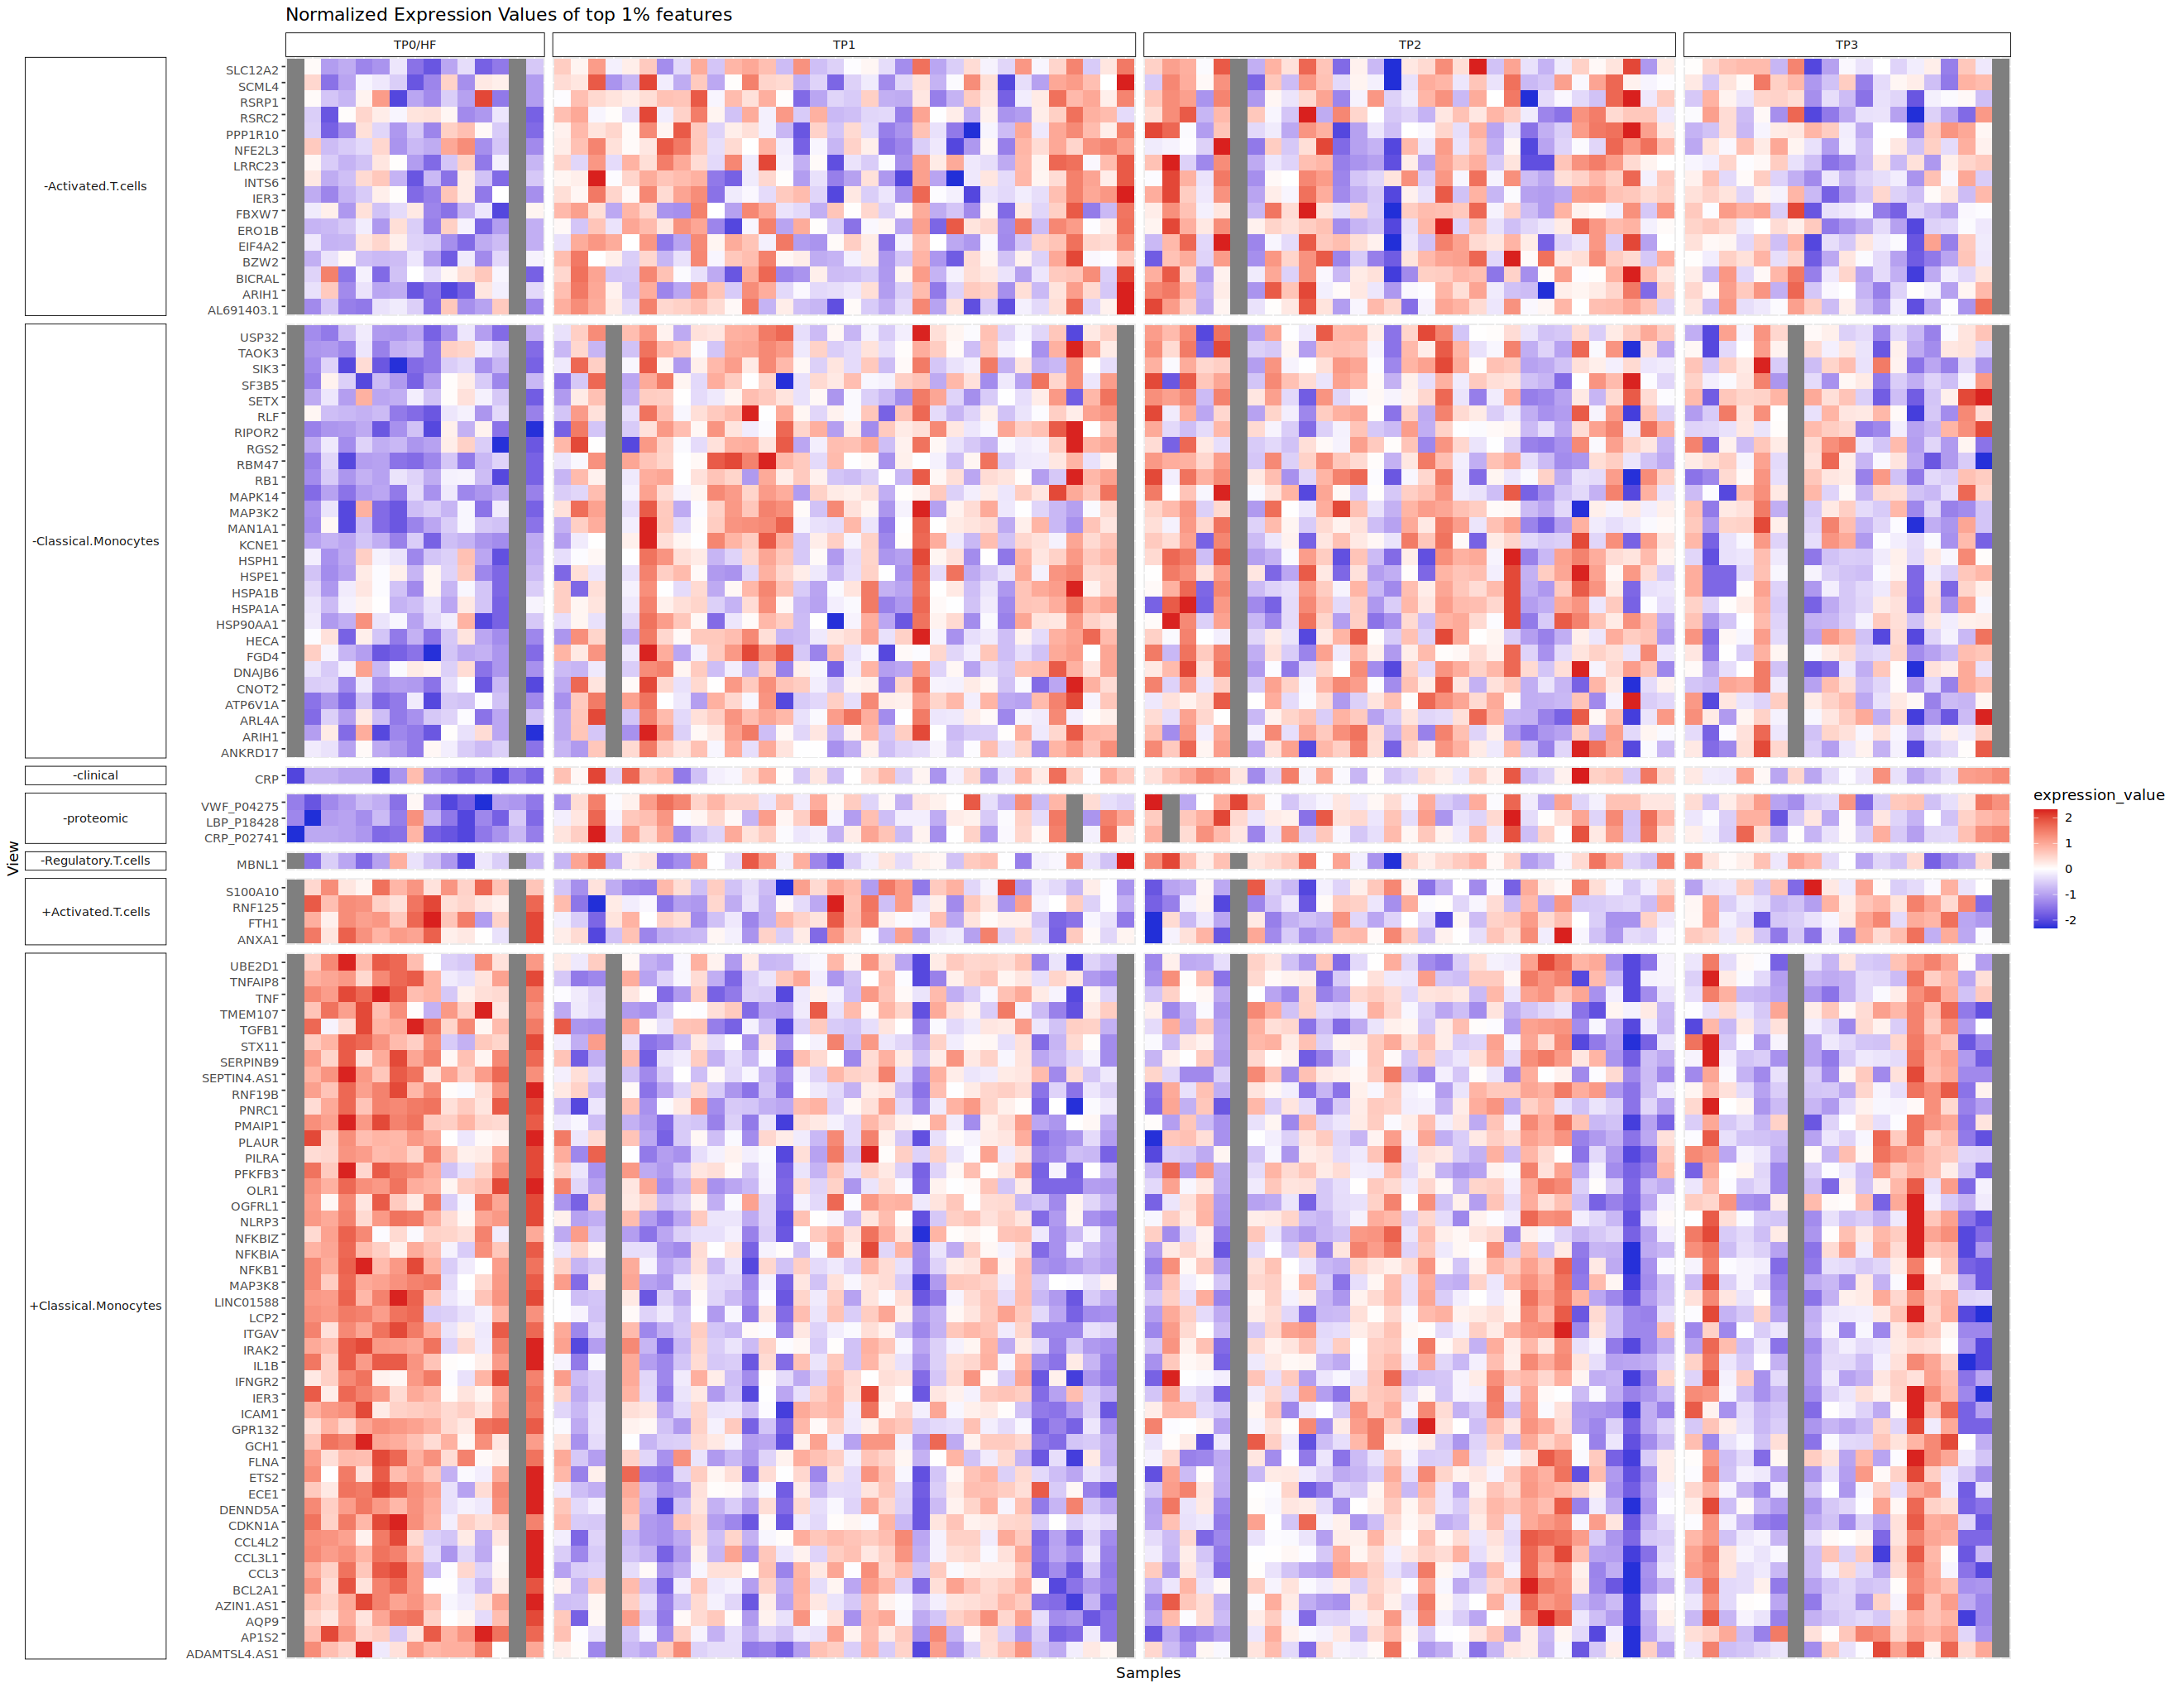

In [99]:
# Example heatmap plot
all_heatmap

In [100]:
### Combined factor and heatamp plots and save the plot

In [101]:
legend =  get_legend(all_heatmap)

In [102]:
options(repr.plot.width=width_par, repr.plot.height=height_par)
combined = ggarrange(all_heatmap + theme(legend.position = 'none'),
         factor_value_all_bar + 
          theme(axis.text.y = element_blank(),axis.ticks.y = element_blank(),axis.title.y = element_blank(), strip.background.y = element_blank() , strip.text.y = element_blank()),  
         nrow=1, widths = c(4,1), align = 'h')
combined = annotate_figure(combined, right = legend)

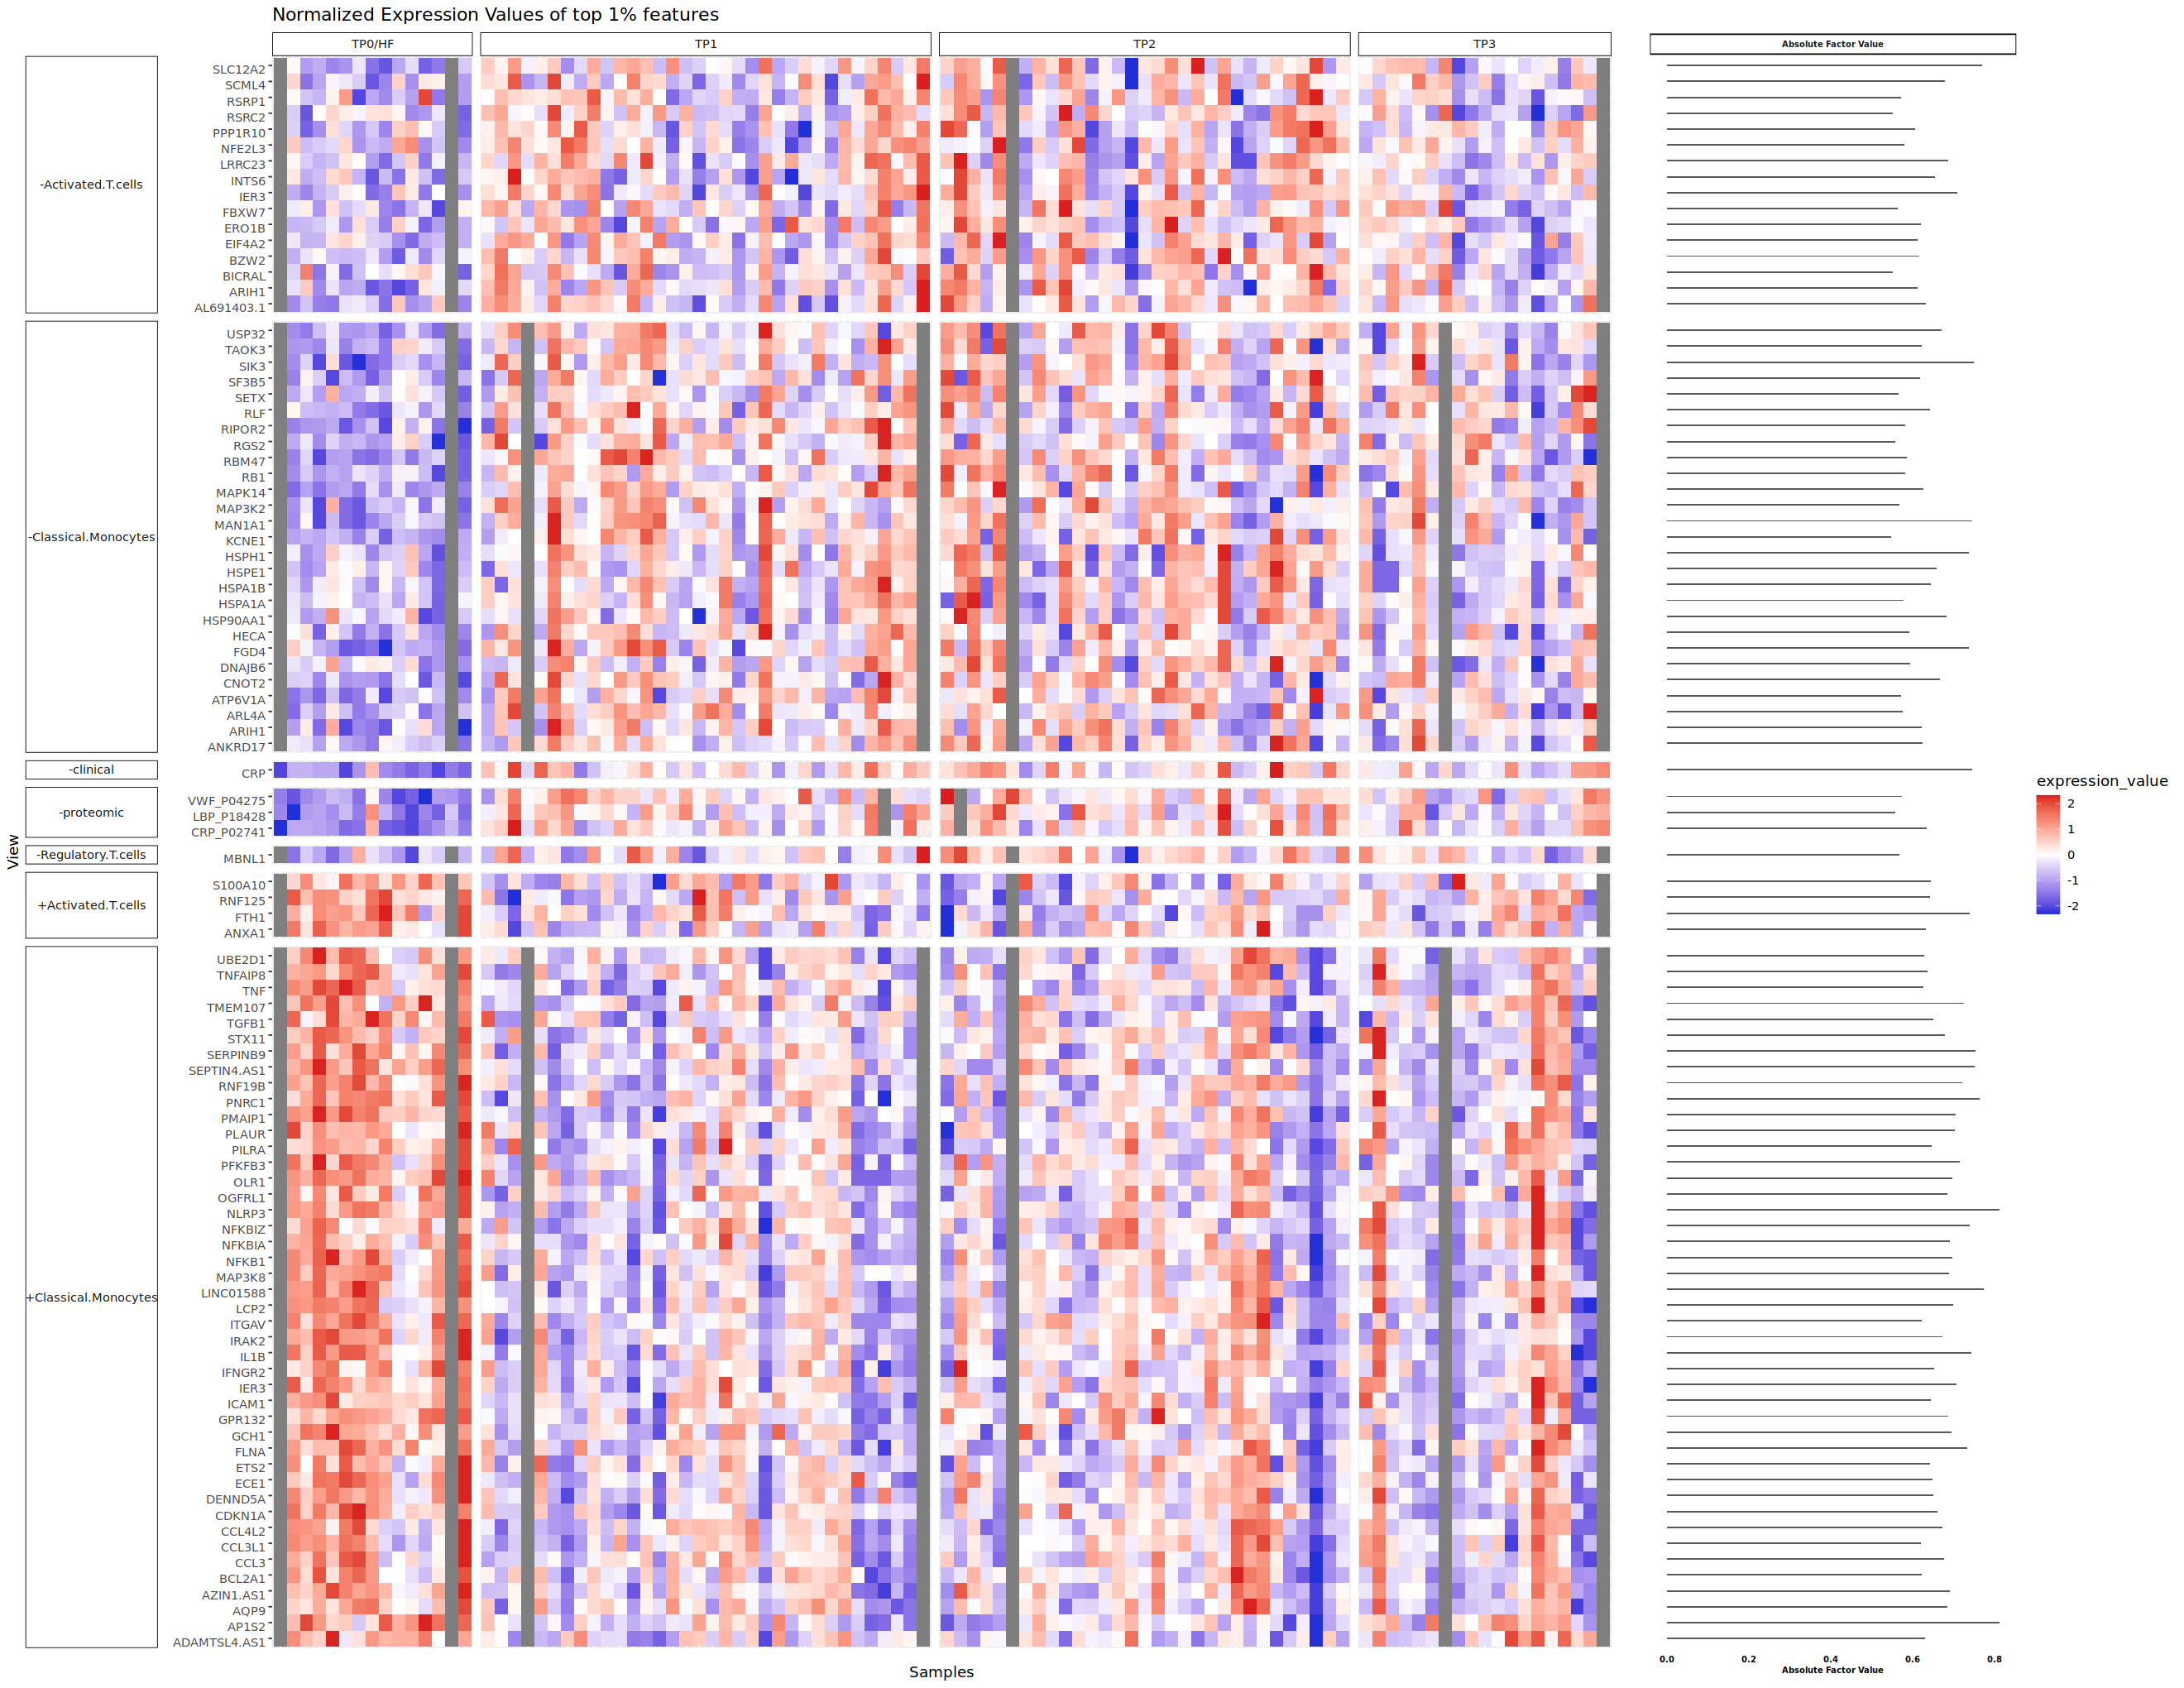

In [103]:
combined

In [104]:
head(heatmap_data)

,sample_id,variable_name,type.x,gene.x,expression_value,type.y,variable,value,view,gene.y,⋯,Leukocyte,Troponin.T,Plt.Count,IL.6,Lactate,NTproBNP,CK,CK.MB,Crea,facet2
,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<fct>,<dbl>,<chr>,<chr>,⋯,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<dbl>,<chr>
1,HF1,Classical.Monocytes__HSPA1B,Classical.Monocytes,HSPA1B,NA,Classical.Monocytes,Factor3,-0.6441615,Classical.Monocytes,HSPA1B,⋯,10.9,0.031,287,NA,NA,NA,80,21,0.8,TP0/HF
2,HF1,Activated.T.cells__AL691403.1,Activated.T.cells,AL691403.1,NA,Activated.T.cells,Factor3,-0.6313970,Activated.T.cells,AL691403.1,⋯,10.9,0.031,287,NA,NA,NA,80,21,0.8,TP0/HF
3,HF1,Activated.T.cells__ARIH1,Activated.T.cells,ARIH1,NA,Activated.T.cells,Factor3,-0.6121915,Activated.T.cells,ARIH1,⋯,10.9,0.031,287,NA,NA,NA,80,21,0.8,TP0/HF
4,HF1,Classical.Monocytes__SEPTIN4.AS1,Classical.Monocytes,SEPTIN4.AS1,NA,Classical.Monocytes,Factor3,0.7506818,Classical.Monocytes,SEPTIN4.AS1,⋯,10.9,0.031,287,NA,NA,NA,80,21,0.8,TP0/HF
5,HF1,Classical.Monocytes__OGFRL1,Classical.Monocytes,OGFRL1,NA,Classical.Monocytes,Factor3,0.6848860,Classical.Monocytes,OGFRL1,⋯,10.9,0.031,287,NA,NA,NA,80,21,0.8,TP0/HF
6,HF1,Classical.Monocytes__USP32,Classical.Monocytes,USP32,NA,Classical.Monocytes,Factor3,-0.6709839,Classical.Monocytes,USP32,⋯,10.9,0.031,287,NA,NA,NA,80,21,0.8,TP0/HF


In [105]:
#based = all_heatmap

In [106]:
pdf(paste0('figures/05_figures/', figure_name,view_var, '_', factor_var, '_',  top_variable_fraction,  mofa_name, '.pdf'), width =width_par, height =height_par)
#print(based)
print(combined)
dev.off()

png 
  2

In [107]:
### Inform about finalized execution

In [108]:
popup_function_pos('05_Downstream_Investigate_Features_Heatmap: Execution Finished')

In [109]:
Sys.sleep(20)
popup_function_info('05_Downstream_Investigate_Features_Heatmap')